In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
fund = pd.read_csv("data/raw/01_fund_master.csv")
nav = pd.read_csv("data/raw/02_nav_history.csv")
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("data/raw/05_category_inflows.csv")
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("data/raw/07_scheme_performance.csv")
investor = pd.read_csv("data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

In [4]:
print(fund.head())
print(nav.head())
print(aum.head())
print(sip.head())

   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \

In [5]:
fund.isnull().sum()

nav.isnull().sum()

aum.isnull().sum()

sip.isnull().sum()

month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

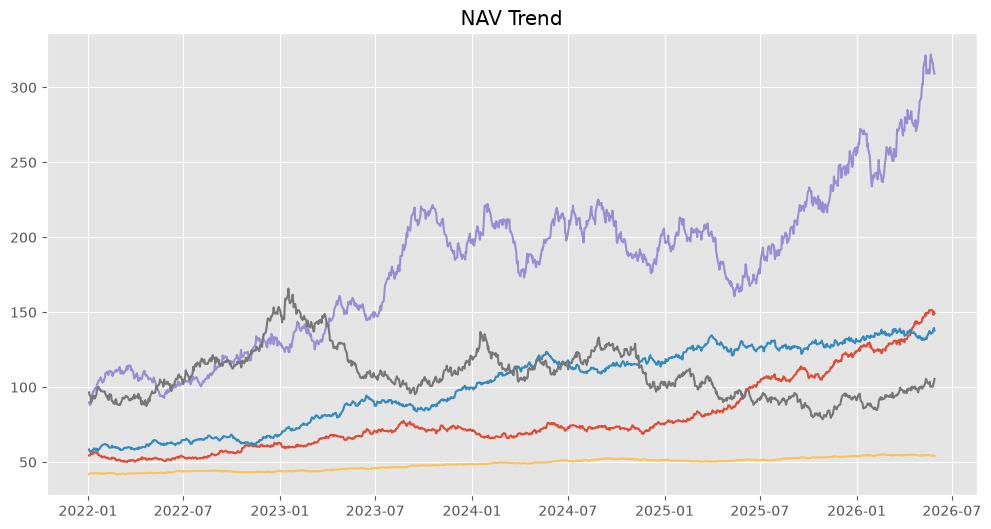

In [6]:
nav["date"] = pd.to_datetime(nav["date"])

plt.figure(figsize=(12,6))

for code in nav["amfi_code"].unique()[:5]:
    temp = nav[nav["amfi_code"]==code]
    plt.plot(temp["date"],temp["nav"])

plt.title("NAV Trend")
plt.show()

In [7]:
plt.savefig("nav_trend.png")

<Figure size 640x480 with 0 Axes>

In [8]:
plt.figure(figsize=(10,6))

sns.barplot(data=aum,
            x="year",
            y="aum_cr",
            hue="fund_house")

plt.xticks(rotation=45)
plt.show()

ValueError: Could not interpret value `year` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [9]:
print(aum.columns)
aum.head()

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [10]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


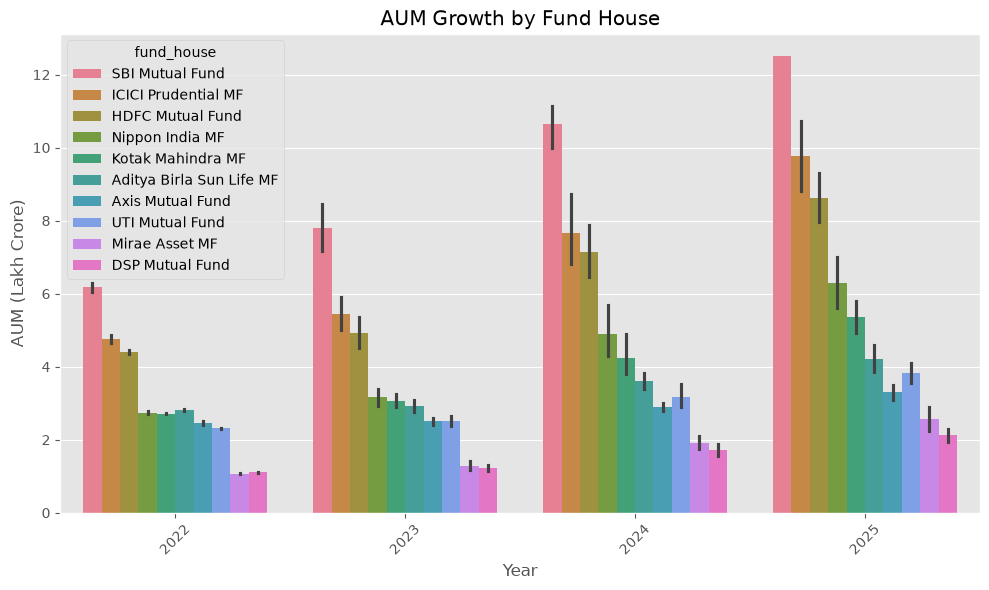

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Create year column
aum["year"] = aum["date"].dt.year

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
plt.savefig("aum_growth_bar_chart.png", dpi=300, bbox_inches="tight")
print("aum_growth_bar_chart.png saved successfully!")

aum_growth_bar_chart.png saved successfully!


<Figure size 640x480 with 0 Axes>

In [13]:
print(sip.columns)
sip.head()

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


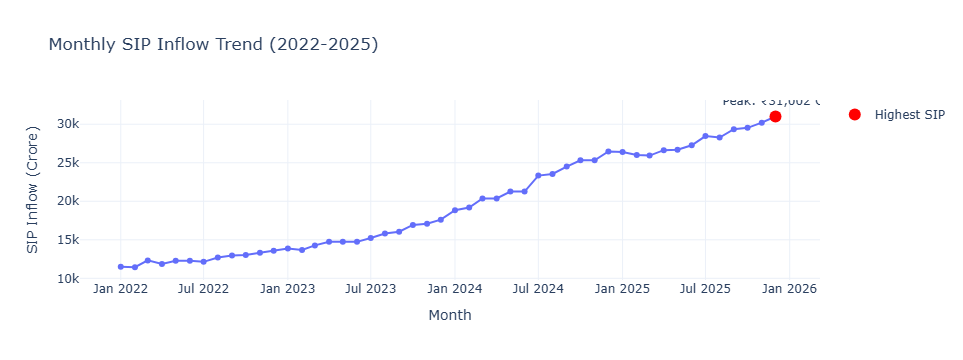

sip_inflow_trend.html saved successfully!


In [14]:
import pandas as pd
import plotly.express as px

# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Create interactive line chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)",
    markers=True
)

# Highlight maximum SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_scatter(
    x=[max_row["month"]],
    y=[max_row["sip_inflow_crore"]],
    mode="markers+text",
    marker=dict(size=12, color="red"),
    text=[f'Peak: ₹{max_row["sip_inflow_crore"]:,} Cr'],
    textposition="top center",
    name="Highest SIP"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crore)",
    template="plotly_white"
)

fig.show()

# Save interactive chart
fig.write_html("sip_inflow_trend.html")

print("sip_inflow_trend.html saved successfully!")

In [15]:
pivot=category.pivot(index="category",
                     columns="month",
                     values="net_inflow")

plt.figure(figsize=(12,8))

sns.heatmap(pivot,cmap="RdYlGn")

plt.show()

KeyError: 'net_inflow'

In [16]:
print(category.columns)
category.head()

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


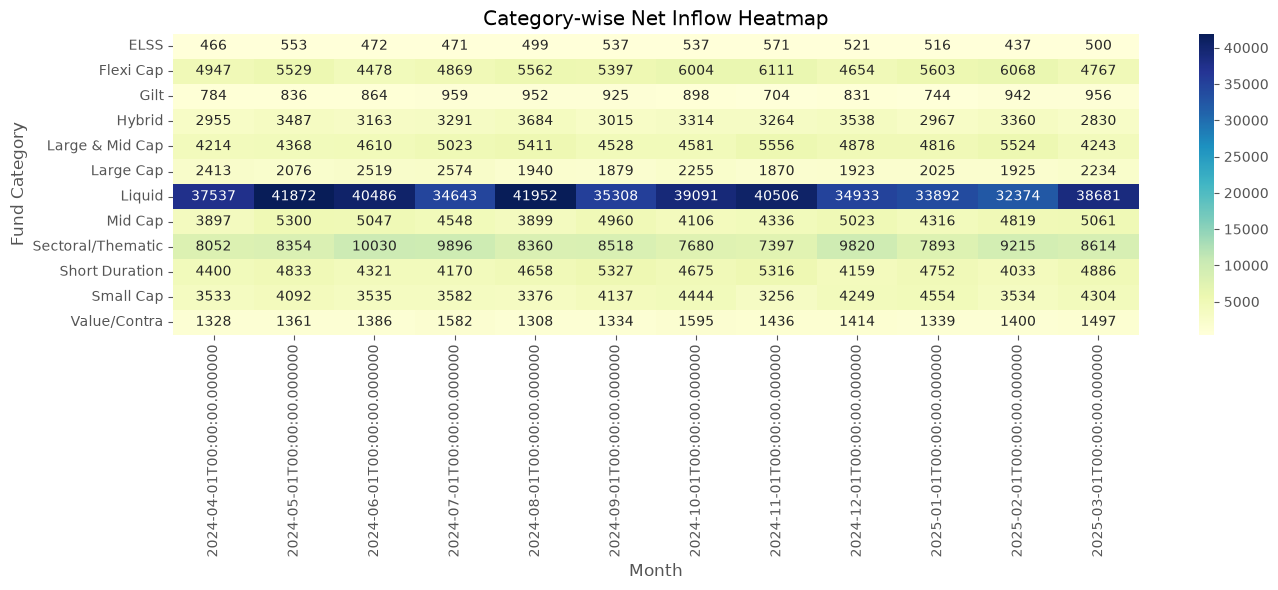

category_inflow_heatmap.png saved successfully!


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Plot heatmap
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig("category_inflow_heatmap.png", dpi=300)

plt.show()

print("category_inflow_heatmap.png saved successfully!")

In [18]:
print(investor.columns)
investor.head()print(investor.columns)
investor.head()

SyntaxError: invalid syntax (3975908397.py, line 2)

In [19]:
print(investor.columns)
investor.head()

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


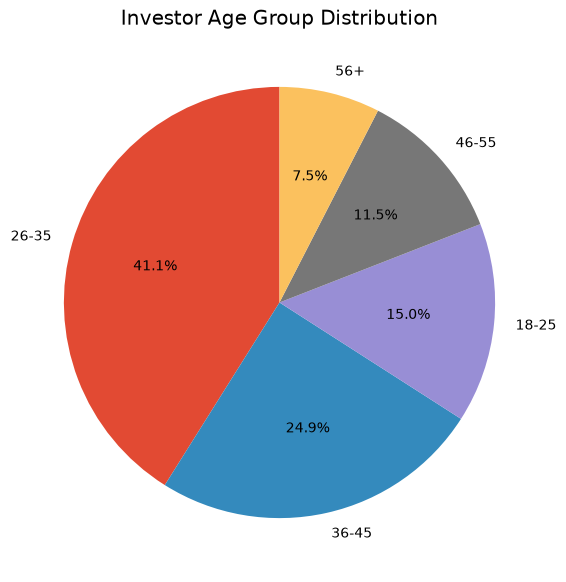

age_group_distribution.png saved successfully!


In [20]:
import matplotlib.pyplot as plt

age_counts = investor["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig("age_group_distribution.png", dpi=300)

plt.show()

print("age_group_distribution.png saved successfully!")

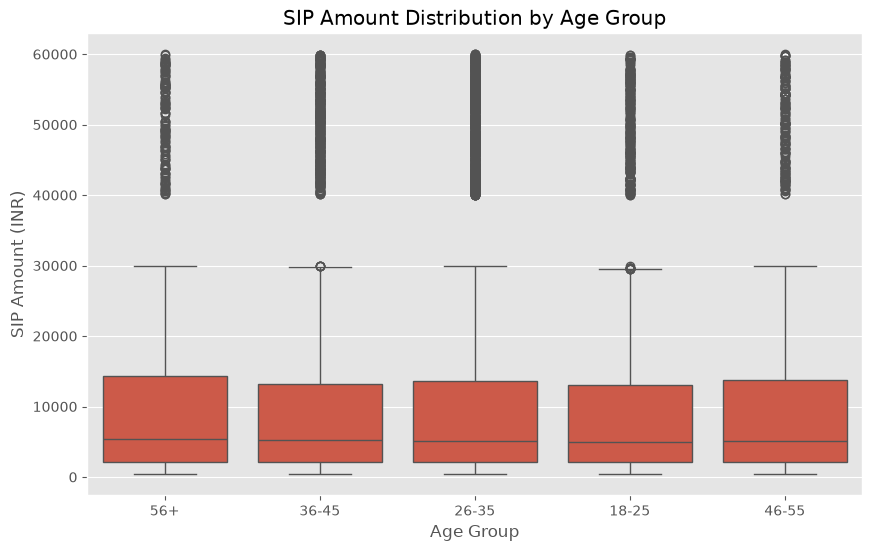

sip_boxplot_age_group.png saved successfully!


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only SIP transactions
sip_data = investor[investor["transaction_type"] == "SIP"]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (INR)")

plt.savefig("sip_boxplot_age_group.png", dpi=300)

plt.show()

print("sip_boxplot_age_group.png saved successfully!")

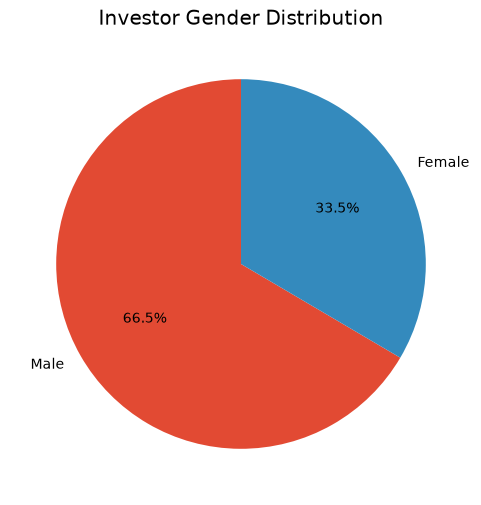

gender_distribution.png saved successfully!


In [22]:
gender_counts = investor["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")

plt.savefig("gender_distribution.png", dpi=300)

plt.show()

print("gender_distribution.png saved successfully!")

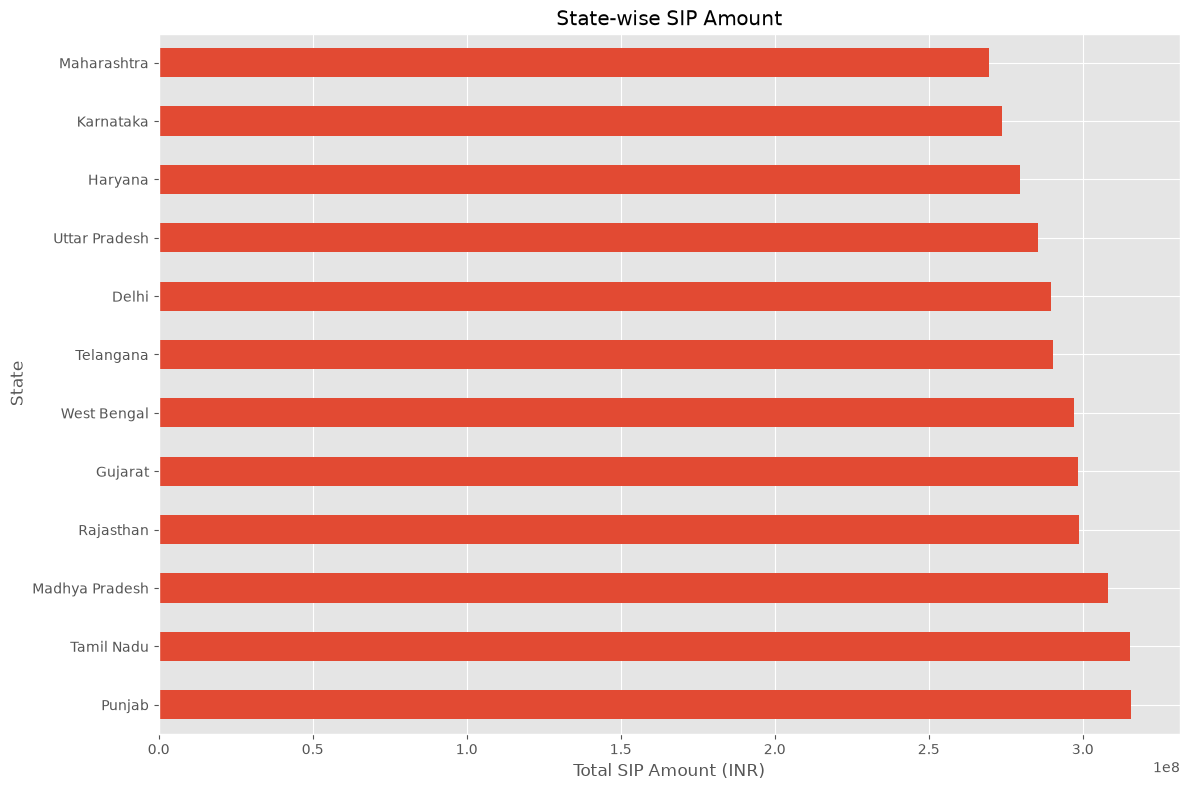

state_wise_sip_amount.png saved successfully!


In [23]:
import matplotlib.pyplot as plt

state_data = (
    investor.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_data.plot(kind="barh")

plt.title("State-wise SIP Amount")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("state_wise_sip_amount.png", dpi=300)

plt.show()

print("state_wise_sip_amount.png saved successfully!")

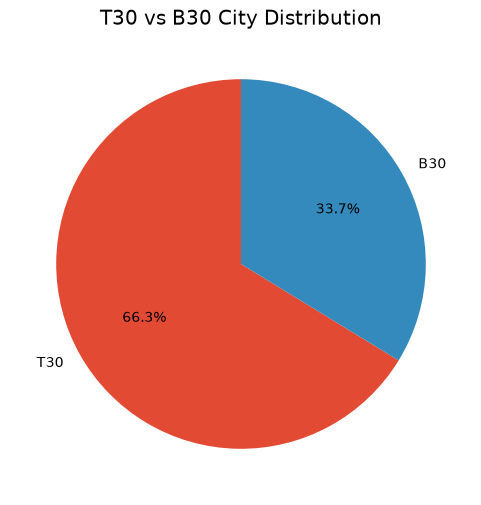

city_tier_distribution.png saved successfully!


In [24]:
city_data = investor["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city_data,
    labels=city_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Distribution")

plt.savefig("city_tier_distribution.png", dpi=300)

plt.show()

print("city_tier_distribution.png saved successfully!")

In [25]:
print(folio.columns)
folio.head()

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


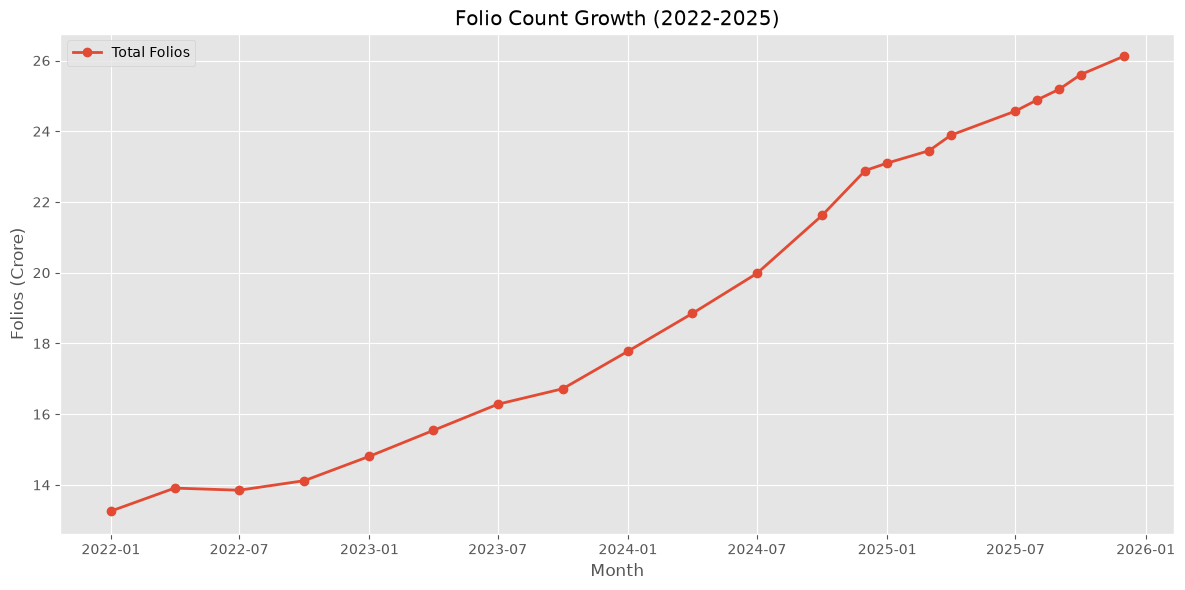

folio_count_growth.png saved successfully!


In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert month column
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2,
    label="Total Folios"
)

plt.title("Folio Count Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("folio_count_growth.png", dpi=300)

plt.show()

print("folio_count_growth.png saved successfully!")

In [27]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [28]:
print(holdings.columns)

NameError: name 'holdings' is not defined

In [29]:
%who DataFrame

aum	 benchmark	 category	 folio	 fund	 heatmap_data	 investor	 nav	 performance	 
portfolio	 sip	 sip_data	 temp	 


In [30]:
print(portfolio.columns)
portfolio.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [31]:
print(nav["amfi_code"].nunique())

40


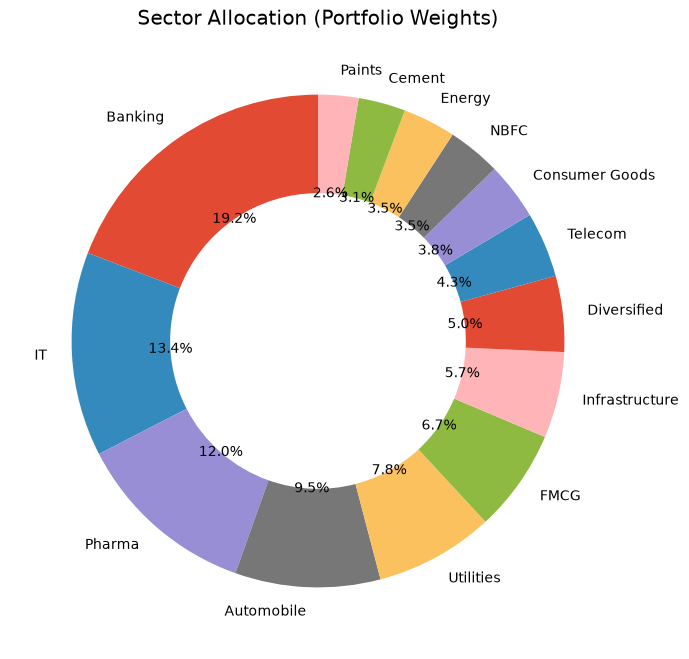

sector_allocation_donut.png saved successfully!


In [32]:
import matplotlib.pyplot as plt

sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation (Portfolio Weights)")

plt.savefig("sector_allocation_donut.png", dpi=300)

plt.show()

print("sector_allocation_donut.png saved successfully!")

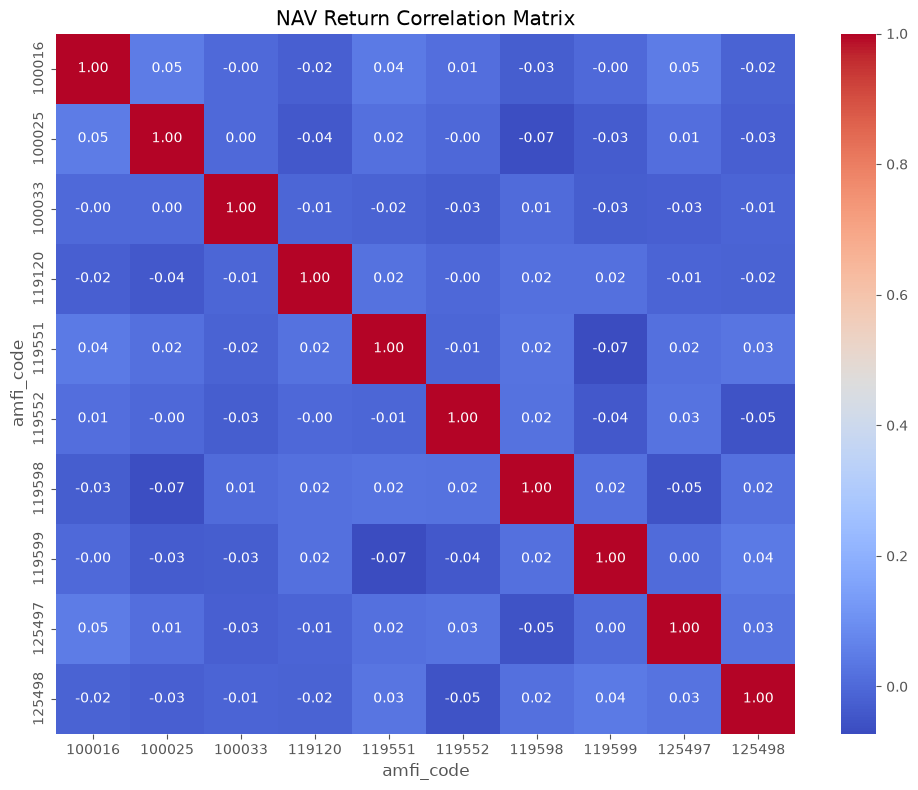

nav_correlation_matrix.png saved successfully!


In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Select first 10 funds
codes = nav["amfi_code"].unique()[:10]

nav10 = nav[nav["amfi_code"].isin(codes)]

# Pivot table
pivot = nav10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Daily returns
returns = pivot.pct_change()

# Correlation matrix
corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()

plt.savefig("nav_correlation_matrix.png", dpi=300)

plt.show()

print("nav_correlation_matrix.png saved successfully!")

# Top 10 EDA Findings

1. NAV values showed a consistent upward trend across most mutual funds.
2. AUM increased steadily from 2022 to 2025, indicating strong industry growth.
3. SBI Mutual Fund maintained the highest Assets Under Management.
4. SIP inflows reached their highest level towards the end of 2025.
5. Liquid and Flexi Cap funds attracted significant investor inflows.
6. Male investors represented approximately two-thirds of the investor base.
7. T30 cities accounted for around two-thirds of total investments.
8. Total folio counts increased continuously throughout the analysis period.
9. Banking, Utilities, Pharma, and Diversified sectors held major portfolio weights.
10. Most selected mutual funds showed positive correlations in daily NAV returns.